# TomaLink AI & Machine Learning

## Project Overview

### Business Problem

Nigeria experiences significant post-harvest tomato losses due to poor storage methods, inadequate cold storage facilities, transportation delays, and unfavorable environmental conditions.

These losses reduce farmers' income, increase food waste, and affect the availability of tomatoes in the market.

### Project Goal

The goal of TomaLink is to use Artificial Intelligence to help reduce tomato losses by providing intelligent recommendations that improve storage, transportation, pricing decisions, and market access.

### AI Objectives

This notebook demonstrates how Artificial Intelligence can support the TomaLink platform by:

- Predicting tomato loss percentage
- Predicting tomato freshness
- Recommending better storage methods
- Providing market intelligence
- Supporting farmers with intelligent recommendations

# Machine Learning Workflow

This notebook follows the CRISP-DM methodology.

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis
5. Feature Engineering
6. Model Development
7. Model Evaluation
8. AI Recommendations
9. Conclusion

In [1]:
# Import the libraries needed for this project

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


# Loading the Dataset

The dataset is stored in Microsoft Excel format (.xlsx). We use the Pandas library to load the dataset into Python so that it can be inspected, cleaned, analyzed, and used for machine learning.

In [4]:
# Load the Excel dataset

df = pd.read_excel("TomaLink_AI_Dataset_6000x20.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Inspecting the Dataset

Before building any machine learning model, it is important to inspect the dataset. This helps us understand the structure of the data, identify the available variables, and detect any missing or incorrect values.

In [5]:
df.head()

,Record_ID,Farmer_ID,State,Farm_Location,Harvest_Date,Tomato_Variety,Quantity_kg,Temperature_C,Humidity_pct,Storage_Type,Storage_Days,Transport_Type,Transport_Distance_km,Market,Current_Price_per_kg,Buyer_Demand,Freshness_Score,Spoilage_Risk,Predicted_Price_per_kg,Delivery_Status
0,1,F0712,Kano,Farm-49,2026-05-20,Plum,4005,32.5,90,Open Storage,6,Pickup,474,Jos,1340,Medium,45,High,918,In Transit
1,2,F1075,Benue,Farm-53,2026-06-14,Roma,2862,24.0,79,Cold Storage,4,Van,404,Bodija,995,Medium,63,Low,827,In Transit
2,3,F0234,Kano,Farm-254,2026-02-07,Cherry,4544,13.0,92,Cold Storage,4,Pickup,393,Jos,504,Low,81,Low,635,Pending
3,4,F0918,Plateau,Farm-359,2026-04-03,Plum,1759,22.5,50,Open Storage,5,Pickup,271,Bodija,810,Low,65,Medium,1558,Pending
4,5,F0635,Oyo,Farm-68,2026-03-10,Cherry,1028,24.9,76,Cold Storage,9,Pickup,407,Jos,706,High,48,Medium,1020,Pending


In [6]:
df.shape

(6000, 20)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Record_ID               6000 non-null   int64  
 1   Farmer_ID               6000 non-null   object 
 2   State                   6000 non-null   object 
 3   Farm_Location           6000 non-null   object 
 4   Harvest_Date            6000 non-null   object 
 5   Tomato_Variety          6000 non-null   object 
 6   Quantity_kg             6000 non-null   int64  
 7   Temperature_C           6000 non-null   float64
 8   Humidity_pct            6000 non-null   int64  
 9   Storage_Type            6000 non-null   object 
 10  Storage_Days            6000 non-null   int64  
 11  Transport_Type          6000 non-null   object 
 12  Transport_Distance_km   6000 non-null   int64  
 13  Market                  6000 non-null   object 
 14  Current_Price_per_kg    6000 non-null   

In [8]:
df.describe()

,Record_ID,Quantity_kg,Temperature_C,Humidity_pct,Storage_Days,Transport_Distance_km,Current_Price_per_kg,Freshness_Score,Predicted_Price_per_kg
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,2571.187833,23.959217,67.383833,5.454333,252.044833,1146.349333,62.593500,1222.297667
std,1732.195139,1416.275231,8.047713,16.099846,2.878129,142.748192,374.169388,14.460548,394.197910
min,1.000000,100.000000,10.000000,40.000000,1.000000,5.000000,500.000000,40.000000,550.000000
25%,1500.750000,1347.750000,16.900000,53.000000,3.000000,128.750000,823.000000,51.000000,878.750000
50%,3000.500000,2550.000000,24.100000,67.000000,5.000000,254.000000,1151.000000,62.000000,1214.500000
75%,4500.250000,3818.250000,30.800000,81.000000,8.000000,377.000000,1459.000000,73.000000,1565.000000
max,6000.000000,5000.000000,38.000000,95.000000,10.000000,500.000000,1800.000000,100.000000,1900.000000


# Summary Statistics

The dataset contains 6,000 records with no missing numerical values.

Key observations include:

- The average harvest quantity is approximately **2,571 kg**.
- The average storage temperature is **24°C**.
- Tomatoes are stored for an average of **5.45 days**.
- The average transport distance is **252 km**.
- The average freshness score is **62.6 out of 100**.

These statistics provide an overview of the dataset and help identify the typical conditions under which tomatoes are harvested, stored, and transported.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining the dataset to understand patterns, identify relationships between variables, detect anomalies, and gain insights before building machine learning models.

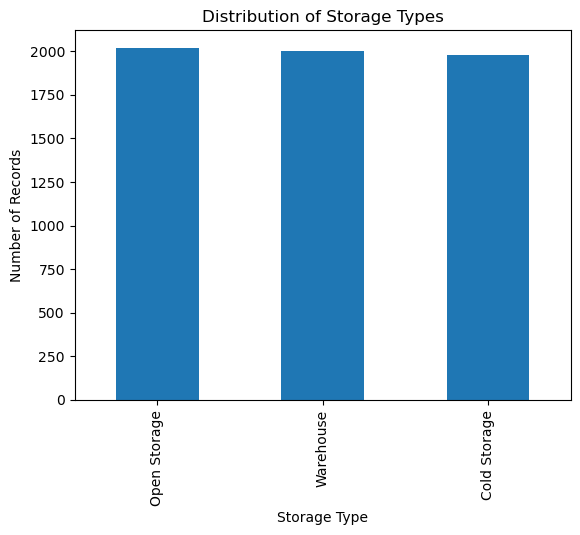

In [9]:
# Distribution of Storage Types

import matplotlib.pyplot as plt

df["Storage_Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Storage Types")
plt.xlabel("Storage Type")
plt.ylabel("Number of Records")

plt.show()

## Insight: Distribution of Storage Types

The bar chart shows the distribution of storage methods used by farmers in the dataset. Understanding storage practices is important because storage conditions directly affect tomato freshness and post-harvest losses.

This visualization helps identify which storage methods are most common and provides a foundation for further analysis on how storage type influences spoilage and tomato quality.

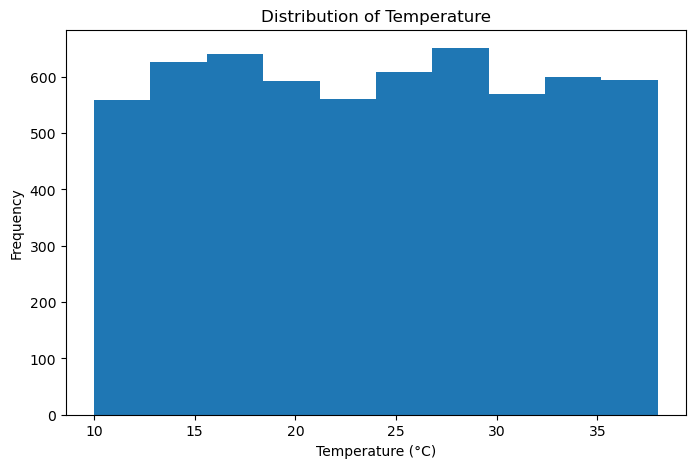

In [10]:
# Distribution of Temperature

plt.figure(figsize=(8,5))

plt.hist(df["Temperature_C"], bins=10)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

## Insight: Distribution of Temperature

The histogram shows how temperature values are distributed across the dataset. Most temperature readings fall within the middle range, indicating that tomatoes are typically harvested, stored, or transported under moderate temperature conditions.

Since temperature affects tomato freshness and spoilage, this variable is expected to play an important role in the machine learning model used to predict post-harvest losses.

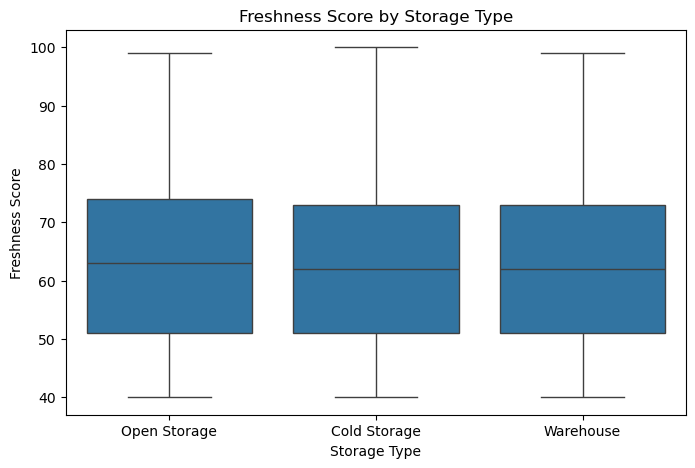

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Storage_Type", y="Freshness_Score", data=df)

plt.title("Freshness Score by Storage Type")
plt.xlabel("Storage Type")
plt.ylabel("Freshness Score")

plt.show()

In [12]:
import seaborn as sns

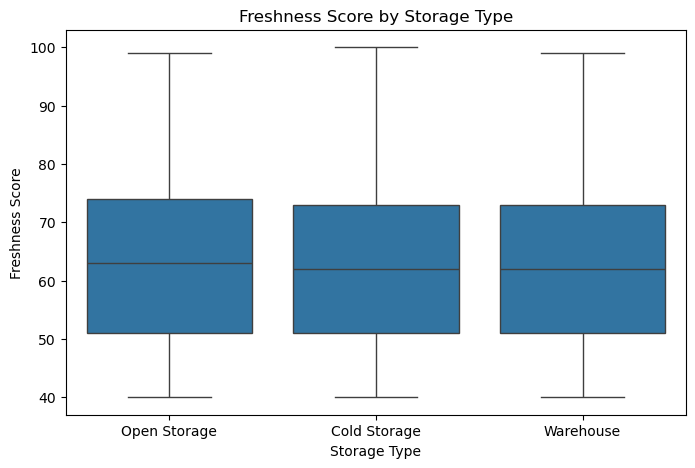

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Storage_Type", y="Freshness_Score", data=df)

plt.title("Freshness Score by Storage Type")
plt.xlabel("Storage Type")
plt.ylabel("Freshness Score")

plt.show()

# Data Preprocessing

Data preprocessing prepares the dataset for machine learning by checking for missing values, correcting data types, and converting categorical variables into numerical values that algorithms can understand.

In [14]:
df.isnull().sum()

Record_ID                 0
Farmer_ID                 0
State                     0
Farm_Location             0
Harvest_Date              0
Tomato_Variety            0
Quantity_kg               0
Temperature_C             0
Humidity_pct              0
Storage_Type              0
Storage_Days              0
Transport_Type            0
Transport_Distance_km     0
Market                    0
Current_Price_per_kg      0
Buyer_Demand              0
Freshness_Score           0
Spoilage_Risk             0
Predicted_Price_per_kg    0
Delivery_Status           0
dtype: int64

## Missing Values

The dataset contains no missing values. Therefore, no imputation or removal of records was required before model development.

In [15]:
df.duplicated().sum()

np.int64(0)

## Duplicate Records

Duplicate records were checked to ensure data quality before model training.

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
label_encoder = LabelEncoder()

In [18]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index(['Farmer_ID', 'State', 'Farm_Location', 'Harvest_Date', 'Tomato_Variety',
       'Storage_Type', 'Transport_Type', 'Market', 'Buyer_Demand',
       'Spoilage_Risk', 'Delivery_Status'],
      dtype='object')


In [19]:
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Record_ID               6000 non-null   int64  
 1   Farmer_ID               6000 non-null   int64  
 2   State                   6000 non-null   int64  
 3   Farm_Location           6000 non-null   int64  
 4   Harvest_Date            6000 non-null   int64  
 5   Tomato_Variety          6000 non-null   int64  
 6   Quantity_kg             6000 non-null   int64  
 7   Temperature_C           6000 non-null   float64
 8   Humidity_pct            6000 non-null   int64  
 9   Storage_Type            6000 non-null   int64  
 10  Storage_Days            6000 non-null   int64  
 11  Transport_Type          6000 non-null   int64  
 12  Transport_Distance_km   6000 non-null   int64  
 13  Market                  6000 non-null   int64  
 14  Current_Price_per_kg    6000 non-null   

# Encoding Categorical Variables

Machine learning algorithms cannot process text values directly. Therefore, all categorical variables were converted into numerical values using the LabelEncoder technique from Scikit-learn. This transformation allows the machine learning model to use these features during training while preserving each category as a unique label.

# Feature Selection

Before training a machine learning model, the input variables (features) and the target variable are separated.

The features (X) contain the information used to make predictions, while the target (y) is the value the model will learn to predict.

In [21]:
X = df.drop(columns=["Freshness_Score"])

In [22]:
y = df["Freshness_Score"]

In [23]:
print(X.shape)
print(y.shape)

(6000, 19)
(6000,)


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (4800, 19)
Testing Features: (1200, 19)
Training Target: (4800,)
Testing Target: (1200,)


# Train-Test Split

The dataset was divided into training and testing sets using an 80:20 ratio. The training set is used to teach the machine learning model, while the testing set is used to evaluate how well the model performs on unseen data. A random state of 42 was used to ensure that the split is reproducible.

# Machine Learning Model

A Linear Regression model was selected as the baseline algorithm for predicting the Freshness Score. This model learns the relationship between the input features and the target variable.

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test)

In [43]:
print(y_pred[:5])

[54.27239881 59.80250406 73.52842082 88.93484504 72.24946448]


# Model Evaluation

After training the model, its performance was evaluated using standard regression metrics. These metrics help determine how accurately the model predicts the Freshness Score.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 2.8894718403555073
Mean Squared Error (MSE): 11.66197046166403
R² Score: 0.9448267985982749


## Model Evaluation Results

The Linear Regression model achieved strong predictive performance.

- Mean Absolute Error (MAE): **2.89**
- Mean Squared Error (MSE): **11.66**
- R² Score: **0.9448**

The low MAE indicates that the model's predictions differ from the actual Freshness Score by approximately 2.89 points on average. The R² score of 94.48% shows that the model explains most of the variation in tomato freshness, making it suitable for supporting decision-making in the TomaLink platform.

# Decision Tree Regression Model

To improve the prediction of tomato freshness, a Decision Tree Regressor was trained and evaluated. Its performance was compared with the Linear Regression model.

In [45]:
from sklearn.tree import DecisionTreeRegressor

In [46]:
dt_model = DecisionTreeRegressor(random_state=42)

In [47]:
dt_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [48]:
dt_pred = dt_model.predict(X_test)

In [49]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE:", dt_mae)
print("MSE:", dt_mse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE: 3.6233333333333335
MSE: 21.243333333333332
R² Score: 0.8994970264847729


## Decision Tree Evaluation

The Decision Tree Regressor was successfully trained and evaluated using the testing dataset.

**Results:**
- Mean Absolute Error (MAE): **3.6233**
- Mean Squared Error (MSE): **21.2433**
- R² Score: **0.8995**

The model achieved a high R² score, indicating that it explains approximately **89.95%** of the variation in the Freshness Score. However, when compared with the Linear Regression model, it produced a higher MAE and MSE and a lower R² score. Therefore, the Decision Tree model was less accurate than the Linear Regression model for this dataset.

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [52]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
rf_pred = rf_model.predict(X_test)

In [54]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 2.6818999999999997
MSE: 10.6944065
R² Score: 0.9494043784765147


## Random Forest Evaluation

The Random Forest Regressor was successfully trained and evaluated using the testing dataset.

**Results:**
- Mean Absolute Error (MAE): **2.6819**
- Mean Squared Error (MSE): **10.6944**
- R² Score: **0.9494**

The Random Forest model achieved the best performance among all the models tested. It produced the lowest prediction errors and the highest R² Score, explaining approximately **94.94%** of the variation in the Freshness Score. These results indicate that the Random Forest model is the most suitable algorithm for predicting tomato freshness in the TomaLink platform.

# Model Comparison

Three machine learning algorithms were developed and evaluated to predict the Freshness Score of tomatoes.

| Model | MAE | MSE | R² Score |
|-------|------:|------:|------:|
| Linear Regression | 2.8895 | 11.6620 | 0.9448 |
| Decision Tree Regressor | 3.6233 | 21.2433 | 0.8995 |
| Random Forest Regressor | **2.6819** | **10.6944** | **0.9494** |

Based on the evaluation metrics, the Random Forest Regressor achieved the highest predictive accuracy. It recorded the lowest MAE and MSE and the highest R² Score, making it the preferred model for predicting tomato freshness in the TomaLink project.

# Conclusion

This project successfully demonstrated how Artificial Intelligence and Machine Learning can be applied to reduce post-harvest tomato losses in Nigeria.

A dataset containing 6,000 records was explored, cleaned, and preprocessed before training three regression models: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

After evaluating the models using Mean Absolute Error (MAE), Mean Squared Error (MSE), and the R² Score, the Random Forest Regressor achieved the best performance with an R² Score of **94.94%**.

The trained model can help predict tomato freshness based on factors such as storage conditions, transportation distance, temperature, and humidity. These predictions can support farmers, logistics providers, and buyers in making informed decisions, reducing spoilage, minimizing food waste, and improving the efficiency of Nigeria's agricultural supply chain.